# EDA — 3D Scene Reconstruction (IMC 2025)
Covers five analyses required for Stage A of the MLOps project:
1. Dataset inventory
2. Blur / sharpness scoring
3. Image orientation distribution
4. Global descriptor norm baseline (drift baseline)
5. Per-scene pairwise similarity matrix

All results are logged to MLflow as the `eda_baselines` experiment.

## 0. Setup

In [1]:
import sys, os, warnings, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2
from pathlib import Path
from collections import defaultdict

warnings.filterwarnings('ignore')

# ── Path setup ────────────────────────────────────────────────────────────
# Adjust ROOT to point to your project root if running from notebooks/
ROOT = Path(os.environ.get('PROJECT_ROOT', '.')).resolve()
DATA_DIR = ROOT / 'data'
SCRIPTS_DIR = ROOT / 'scripts'
PROCESSED_DIR = DATA_DIR / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(SCRIPTS_DIR))

print(f'Project root : {ROOT}')
print(f'Data dir     : {DATA_DIR}')
print(f'Processed dir: {PROCESSED_DIR}')

Project root : /home/yash/ML_Operations/Project
Data dir     : /home/yash/ML_Operations/Project/data
Processed dir: /home/yash/ML_Operations/Project/data/processed


In [2]:
import mlflow

MLFLOW_URI = os.environ.get('MLFLOW_TRACKING_URI', 'http://localhost:5000')
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment('eda_baselines')
print(f'MLflow tracking URI: {MLFLOW_URI}')

MLflow tracking URI: http://localhost:5000


## 1. Dataset inventory

In [3]:
# Load train labels
labels_path = DATA_DIR / 'train_labels.csv'
assert labels_path.exists(), f'Not found: {labels_path}'
df = pd.read_csv(labels_path)

print(f'Total rows      : {len(df):,}')
print(f'Columns         : {list(df.columns)}')
print(f'Datasets        : {df["dataset"].nunique()}')
print(f'Scenes          : {df["scene"].nunique()}')
df.head(3)

Total rows      : 1,945
Columns         : ['dataset', 'scene', 'image', 'rotation_matrix', 'translation_vector']
Datasets        : 13
Scenes          : 30


,dataset,scene,image,rotation_matrix,translation_vector
0,imc2023_haiper,fountain,fountain_image_116.png,0.122655949;0.947713775;-0.294608417;0.1226706...,0.093771314;-0.803560988;2.062001533
1,imc2023_haiper,fountain,fountain_image_108.png,0.474305910;0.359108654;-0.803787832;0.2888416...,0.358946647;-0.797557548;1.910906929
2,imc2023_haiper,fountain,fountain_image_101.png,0.565115476;-0.138485064;-0.813305838;0.506678...,0.146922468;-0.981392596;2.009002852


In [4]:
# Scenes per dataset
scene_counts = df.groupby('dataset')['scene'].nunique().sort_values(ascending=False)

# Images per scene
img_per_scene = df.groupby(['dataset', 'scene']).size()
img_stats = img_per_scene.describe()

print('\nImages per scene stats:')
print(img_stats.to_string())

# Scenes with fewer than 5 images (potential data quality issue)
tiny_scenes = img_per_scene[img_per_scene < 5]
print(f'\nScenes with < 5 images: {len(tiny_scenes)}')
if len(tiny_scenes) > 0:
    print(tiny_scenes)


Images per scene stats:
count     34.000000
mean      57.205882
std       38.827341
min        3.000000
25%       26.500000
50%       55.500000
75%       75.000000
max      200.000000

Scenes with < 5 images: 1
dataset  scene   
ETs      outliers    3
dtype: int64


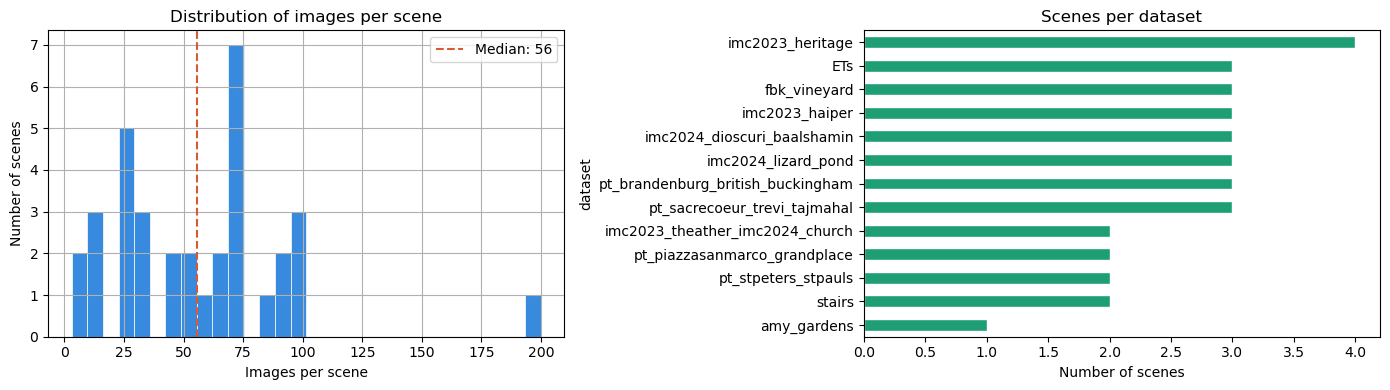

Saved: /home/yash/ML_Operations/Project/data/processed/inventory_plots.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: images per scene distribution
ax = axes[0]
img_per_scene.hist(bins=30, ax=ax, color='#378ADD', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Images per scene')
ax.set_ylabel('Number of scenes')
ax.set_title('Distribution of images per scene')
ax.axvline(img_per_scene.median(), color='#D85A30', linestyle='--',
           linewidth=1.5, label=f'Median: {img_per_scene.median():.0f}')
ax.legend(fontsize=10)

# Plot 2: scenes per dataset
ax2 = axes[1]
scene_counts.plot(kind='barh', ax=ax2, color='#1D9E75', edgecolor='white')
ax2.set_xlabel('Number of scenes')
ax2.set_title('Scenes per dataset')
ax2.invert_yaxis()

plt.tight_layout()
inv_path = str(PROCESSED_DIR / 'inventory_plots.png')
plt.savefig(inv_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {inv_path}')

In [6]:
# Image resolution distribution — sample up to 500 images for speed
all_image_paths = []
for _, row in df.iterrows():
    candidate = DATA_DIR / 'train' / row['dataset'] / row['image']
    if candidate.exists():
        all_image_paths.append(str(candidate))

print(f'Images found on disk: {len(all_image_paths):,} / {len(df):,}')

SAMPLE_N = min(500, len(all_image_paths))
rng = np.random.default_rng(42)
sample_paths = rng.choice(all_image_paths, size=SAMPLE_N, replace=False).tolist()

heights, widths = [], []
for p in sample_paths:
    img = cv2.imread(p)
    if img is not None:
        heights.append(img.shape[0])
        widths.append(img.shape[1])

heights = np.array(heights)
widths  = np.array(widths)
print(f'\nHeight — mean: {heights.mean():.0f}, std: {heights.std():.0f}, min: {heights.min()}, max: {heights.max()}')
print(f'Width  — mean: {widths.mean():.0f},  std: {widths.std():.0f},  min: {widths.min()},  max: {widths.max()}')

Images found on disk: 1,945 / 1,945

Height — mean: 1005, std: 736, min: 240, max: 4032
Width  — mean: 1143,  std: 1158,  min: 360,  max: 6048


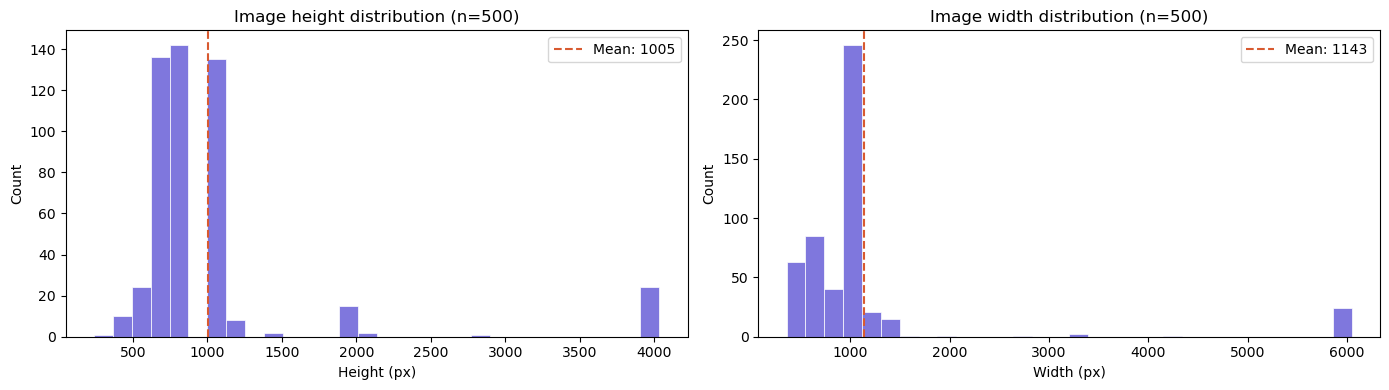

Saved: /home/yash/ML_Operations/Project/data/processed/resolution_hist.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, values, label in zip(axes, [heights, widths], ['Height (px)', 'Width (px)']):
    ax.hist(values, bins=30, color='#7F77DD', edgecolor='white', linewidth=0.5)
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(f'Image {label.split(" ")[0].lower()} distribution (n={len(values)})')
    ax.axvline(np.mean(values), color='#D85A30', linestyle='--',
               linewidth=1.5, label=f'Mean: {np.mean(values):.0f}')
    ax.legend(fontsize=10)

plt.tight_layout()
res_path = str(PROCESSED_DIR / 'resolution_hist.png')
plt.savefig(res_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {res_path}')

## 2. Blur / sharpness scoring

In [8]:
def laplacian_sharpness(path: str) -> float:
    """Laplacian variance — higher = sharper."""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return np.nan
    return float(cv2.Laplacian(img, cv2.CV_64F).var())

print(f'Computing sharpness for {len(sample_paths)} images...')
t0 = time.time()
sharpness_scores = np.array([laplacian_sharpness(p) for p in sample_paths])
sharpness_scores = sharpness_scores[~np.isnan(sharpness_scores)]
print(f'Done in {time.time()-t0:.1f}s')

p10 = float(np.percentile(sharpness_scores, 10))
p50 = float(np.percentile(sharpness_scores, 50))
p90 = float(np.percentile(sharpness_scores, 90))
blurry_count = int((sharpness_scores < 100).sum())

print(f'\nSharpness stats (Laplacian variance):')
print(f'  p10  = {p10:.1f}   ← use as blurry_threshold in DeblurringConfig')
print(f'  p50  = {p50:.1f}')
print(f'  p90  = {p90:.1f}')
print(f'  mean = {sharpness_scores.mean():.1f}')
print(f'  std  = {sharpness_scores.std():.1f}')
print(f'  Images < 100 (likely blurry): {blurry_count} ({100*blurry_count/len(sharpness_scores):.1f}%)')

Computing sharpness for 500 images...
Done in 29.5s

Sharpness stats (Laplacian variance):
  p10  = 93.3   ← use as blurry_threshold in DeblurringConfig
  p50  = 694.1
  p90  = 9631.3
  mean = 2530.2
  std  = 3948.1
  Images < 100 (likely blurry): 57 (11.4%)


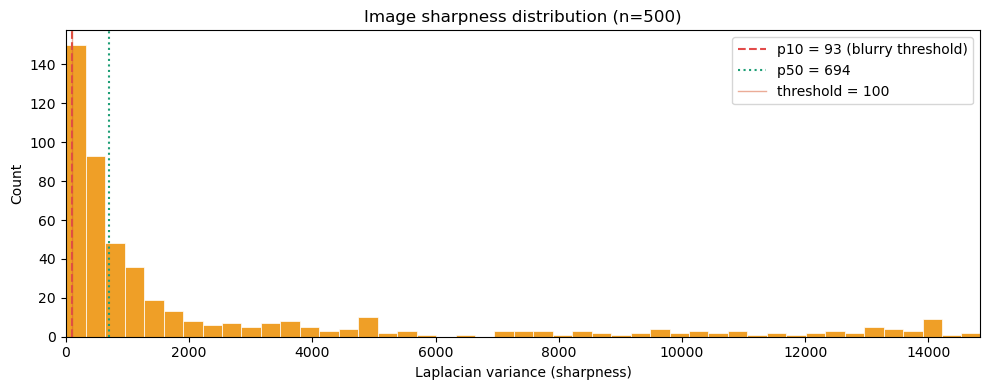

Saved: /home/yash/ML_Operations/Project/data/processed/sharpness_hist.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(sharpness_scores, bins=50, color='#EF9F27', edgecolor='white', linewidth=0.5)
ax.axvline(p10,  color='#E24B4A', linestyle='--', linewidth=1.5, label=f'p10 = {p10:.0f} (blurry threshold)')
ax.axvline(p50,  color='#1D9E75', linestyle=':',  linewidth=1.5, label=f'p50 = {p50:.0f}')
ax.axvline(100,  color='#D85A30', linestyle='-',  linewidth=1.0, alpha=0.5, label='threshold = 100')
ax.set_xlabel('Laplacian variance (sharpness)')
ax.set_ylabel('Count')
ax.set_title(f'Image sharpness distribution (n={len(sharpness_scores)})')
ax.set_xlim(0, np.percentile(sharpness_scores, 99))
ax.legend(fontsize=10)
plt.tight_layout()
sharp_path = str(PROCESSED_DIR / 'sharpness_hist.png')
plt.savefig(sharp_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {sharp_path}')

## 3. Orientation distribution

In [10]:
# Use EXIF orientation to check how many images are not upright.
# Full CheckOrientationHandler requires a GPU model weight —
# EXIF gives a fast proxy for EDA purposes.
from PIL import Image as PILImage

EXIF_ORIENTATION_TAG = 0x112

def get_exif_orientation(path: str) -> int:
    """Returns EXIF orientation value (1 = normal, 3 = 180°, 6 = 90° CW, 8 = 90° CCW)."""
    try:
        with PILImage.open(path) as img:
            exif = img.getexif()
            return int(exif.get(EXIF_ORIENTATION_TAG, 1))
    except Exception:
        return 1

ORI_MAP = {1: 'upright (0°)', 3: 'rotated 180°', 6: 'rotated 90° CW', 8: 'rotated 90° CCW'}

ORI_SAMPLE = min(300, len(sample_paths))
print(f'Checking EXIF orientation on {ORI_SAMPLE} images...')
ori_values = [get_exif_orientation(p) for p in sample_paths[:ORI_SAMPLE]]
ori_series = pd.Series([ORI_MAP.get(v, f'other ({v})') for v in ori_values])
ori_counts = ori_series.value_counts()

print('\nEXIF orientation distribution:')
for label, count in ori_counts.items():
    pct = 100 * count / len(ori_values)
    print(f'  {label:25s}: {count:4d}  ({pct:.1f}%)')

non_upright_pct = 100 * (1 - ori_counts.get('upright (0°)', 0) / len(ori_values))
print(f'\nNon-upright images: {non_upright_pct:.1f}% — ', end='')
if non_upright_pct > 5:
    print('orientation normalization RECOMMENDED')
else:
    print('orientation normalization optional')

Checking EXIF orientation on 300 images...

EXIF orientation distribution:
  upright (0°)             :  300  (100.0%)

Non-upright images: 0.0% — orientation normalization optional


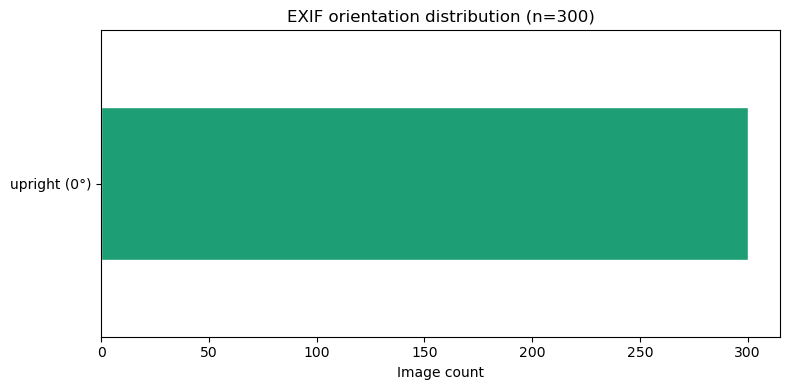

Saved: /home/yash/ML_Operations/Project/data/processed/orientation_dist.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#1D9E75', '#D85A30', '#378ADD', '#7F77DD']
ori_counts.plot(kind='barh', ax=ax, color=colors[:len(ori_counts)], edgecolor='white')
ax.set_xlabel('Image count')
ax.set_title(f'EXIF orientation distribution (n={ORI_SAMPLE})')
ax.invert_yaxis()
plt.tight_layout()
ori_path = str(PROCESSED_DIR / 'orientation_dist.png')
plt.savefig(ori_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {ori_path}')

## 4. Global descriptor norm baseline (drift baseline)

In [12]:
# We compute descriptor norms using ISC (lightest model — no GPU required for EDA).
# If ISC weights are not available, we fall back to a simple HOG descriptor baseline.
import torch

DESC_SAMPLE = min(100, len(sample_paths))
desc_sample_paths = sample_paths[:DESC_SAMPLE]

try:
    from scripts.data import resolve_model_path
    from global_descriptors.isc import ISCGlobalDescriptorExtractor
    from models.config import ISCModelConfig

    isc_conf = ISCModelConfig(weight_path='ISC')
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    extractor = ISCGlobalDescriptorExtractor(conf=isc_conf, device=device)

    from torch.utils.data import DataLoader
    dataset = extractor.create_dataset(desc_sample_paths)
    loader = DataLoader(dataset, batch_size=8, shuffle=False, num_workers=0)

    all_feats = []
    with torch.no_grad():
        for batch in loader:
            f = extractor(batch)
            all_feats.append(f.cpu())
    feats = torch.cat(all_feats, dim=0)  # (N, D)
    descriptor_source = 'ISC'
    print(f'ISC descriptors computed: shape={feats.shape}')

except Exception as e:
    print(f'ISC not available ({e}), falling back to HOG baseline')
    descriptor_source = 'HOG (fallback)'

    hog_desc = cv2.HOGDescriptor()
    hog_feats = []
    for p in desc_sample_paths:
        img = cv2.imread(p)
        if img is None:
            continue
        img_resized = cv2.resize(img, (128, 128))
        gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
        h = hog_desc.compute(gray)
        if h is not None:
            hog_feats.append(h.ravel())
    feats = torch.tensor(np.stack(hog_feats), dtype=torch.float32)  # (N, D)
    print(f'HOG descriptors computed: shape={feats.shape}')

ISC not available (No module named 'clusterings'), falling back to HOG baseline
HOG descriptors computed: shape=torch.Size([100, 34020])


In [13]:
import torch.nn.functional as F

norms = feats.norm(dim=1).numpy()

desc_baseline = {
    'descriptor_source': descriptor_source,
    'n_images': int(len(norms)),
    'descriptor_dim': int(feats.shape[1]),
    'norm_mean': float(norms.mean()),
    'norm_std':  float(norms.std()),
    'norm_min':  float(norms.min()),
    'norm_max':  float(norms.max()),
    'norm_p10':  float(np.percentile(norms, 10)),
    'norm_p50':  float(np.percentile(norms, 50)),
    'norm_p90':  float(np.percentile(norms, 90)),
}

print('Descriptor norm baseline (used for drift detection in Stage 6):')
for k, v in desc_baseline.items():
    print(f'  {k:25s}: {v}')

Descriptor norm baseline (used for drift detection in Stage 6):
  descriptor_source        : HOG (fallback)
  n_images                 : 100
  descriptor_dim           : 34020
  norm_mean                : 30.65304183959961
  norm_std                 : 0.14397242665290833
  norm_min                 : 29.773611068725586
  norm_max                 : 30.70563507080078
  norm_p10                 : 30.64184513092041
  norm_p50                 : 30.691889762878418
  norm_p90                 : 30.70468044281006


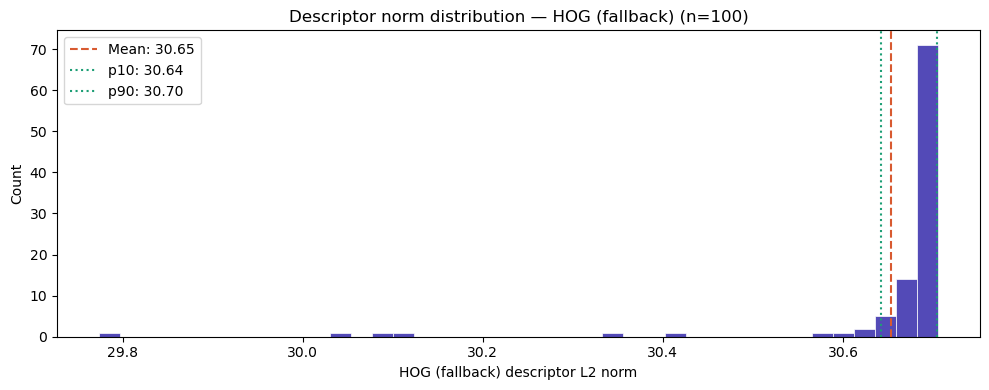

Saved: /home/yash/ML_Operations/Project/data/processed/descriptor_norm_hist.png


In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(norms, bins=40, color='#534AB7', edgecolor='white', linewidth=0.5)
ax.axvline(desc_baseline['norm_mean'], color='#D85A30', linestyle='--',
           linewidth=1.5, label=f'Mean: {desc_baseline["norm_mean"]:.2f}')
ax.axvline(desc_baseline['norm_p10'], color='#1D9E75', linestyle=':',
           linewidth=1.5, label=f'p10: {desc_baseline["norm_p10"]:.2f}')
ax.axvline(desc_baseline['norm_p90'], color='#1D9E75', linestyle=':',
           linewidth=1.5, label=f'p90: {desc_baseline["norm_p90"]:.2f}')
ax.set_xlabel(f'{descriptor_source} descriptor L2 norm')
ax.set_ylabel('Count')
ax.set_title(f'Descriptor norm distribution — {descriptor_source} (n={len(norms)})')
ax.legend(fontsize=10)
plt.tight_layout()
norm_path = str(PROCESSED_DIR / 'descriptor_norm_hist.png')
plt.savefig(norm_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {norm_path}')

## 5. Per-scene pairwise similarity matrix

In [15]:
# Pick 3 representative scenes for visualisation — one small, one medium, one large.
scene_sizes = df.groupby(['dataset', 'scene']).size().reset_index(name='n_images')
scene_sizes = scene_sizes.sort_values('n_images')

# Select scenes: smallest, median, largest
indices = [0, len(scene_sizes)//2, len(scene_sizes)-1]
selected_scenes = scene_sizes.iloc[indices][['dataset', 'scene', 'n_images']]
print('Selected scenes for similarity analysis:')
print(selected_scenes.to_string(index=False))

Selected scenes for similarity analysis:
         dataset    scene  n_images
             ETs outliers         3
imc2023_heritage outliers        61
     amy_gardens    peach       200


In [16]:
def compute_scene_similarity(dataset: str, scene: str, max_imgs: int = 30) -> tuple:
    """Compute pairwise cosine similarity for images in a scene using HOG descriptors."""
    scene_df = df[(df['dataset'] == dataset) & (df['scene'] == scene)].head(max_imgs)
    paths = []
    for _, row in scene_df.iterrows():
        p = DATA_DIR / 'train' / row['dataset'] / row['image']
        if p.exists():
            paths.append(str(p))

    if len(paths) < 2:
        return None, paths

    hog = cv2.HOGDescriptor()
    vecs = []
    for p in paths:
        img = cv2.imread(p)
        if img is None:
            continue
        img_r = cv2.resize(img, (128, 128))
        gray = cv2.cvtColor(img_r, cv2.COLOR_BGR2GRAY)
        h = hog.compute(gray)
        if h is not None:
            vecs.append(h.ravel())

    if len(vecs) < 2:
        return None, paths

    vecs_t = torch.tensor(np.stack(vecs), dtype=torch.float32)
    norm_v = F.normalize(vecs_t, dim=1)
    sim_matrix = (norm_v @ norm_v.T).numpy()
    return sim_matrix, paths

scene_sims = {}
for _, row in selected_scenes.iterrows():
    key = f"{row['dataset']}/{row['scene']}"
    print(f'Computing similarity for {key} ({row["n_images"]} images)...')
    sim, paths = compute_scene_similarity(row['dataset'], row['scene'])
    if sim is not None:
        scene_sims[key] = sim
        mean_off_diag = (sim.sum() - np.trace(sim)) / (sim.shape[0]**2 - sim.shape[0])
        print(f'  mean off-diagonal similarity: {mean_off_diag:.3f}')
print('Done.')

Computing similarity for ETs/outliers (3 images)...
  mean off-diagonal similarity: 0.625
Computing similarity for imc2023_heritage/outliers (61 images)...
  mean off-diagonal similarity: 0.786
Computing similarity for amy_gardens/peach (200 images)...
  mean off-diagonal similarity: 0.897
Done.


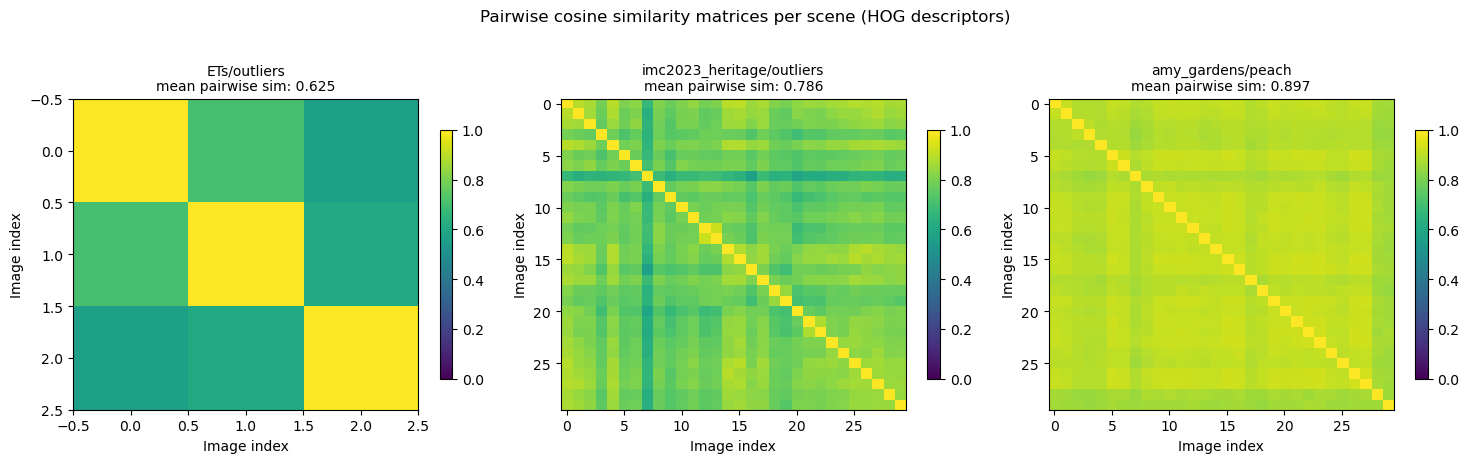

Saved: /home/yash/ML_Operations/Project/data/processed/similarity_matrix.png

Scene difficulty assessment:
  ETs/outliers                            : easy    (mean sim=0.625)
  imc2023_heritage/outliers               : easy    (mean sim=0.786)
  amy_gardens/peach                       : easy    (mean sim=0.897)


In [17]:
n_scenes = len(scene_sims)
fig, axes = plt.subplots(1, max(n_scenes, 1), figsize=(5 * max(n_scenes, 1), 4.5))
if n_scenes == 1:
    axes = [axes]

sim_stats = {}
for ax, (scene_key, sim) in zip(axes, scene_sims.items()):
    im = ax.imshow(sim, cmap='viridis', vmin=0, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.8)
    mean_sim = float((sim.sum() - np.trace(sim)) / max(sim.shape[0]**2 - sim.shape[0], 1))
    ax.set_title(f'{scene_key}\nmean pairwise sim: {mean_sim:.3f}', fontsize=10)
    ax.set_xlabel('Image index')
    ax.set_ylabel('Image index')
    sim_stats[scene_key] = {
        'n_images': sim.shape[0],
        'mean_pairwise_similarity': mean_sim,
        'difficulty': 'easy' if mean_sim > 0.6 else 'medium' if mean_sim > 0.3 else 'hard'
    }

plt.suptitle('Pairwise cosine similarity matrices per scene (HOG descriptors)', y=1.02)
plt.tight_layout()
sim_path = str(PROCESSED_DIR / 'similarity_matrix.png')
plt.savefig(sim_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {sim_path}')

print('\nScene difficulty assessment:')
for k, v in sim_stats.items():
    print(f'  {k:40s}: {v["difficulty"]:6s}  (mean sim={v["mean_pairwise_similarity"]:.3f})')

## 6. Save baselines and log to MLflow

In [18]:
# ── Compile all baseline statistics ───────────────────────────────────────
baselines = {
    'dataset': {
        'total_images': int(len(all_image_paths)),
        'total_scenes': int(img_per_scene.shape[0]),
        'total_datasets': int(df['dataset'].nunique()),
        'img_per_scene_mean': float(img_per_scene.mean()),
        'img_per_scene_std':  float(img_per_scene.std()),
        'img_per_scene_min':  int(img_per_scene.min()),
        'img_per_scene_max':  int(img_per_scene.max()),
        'tiny_scenes_count':  int(len(tiny_scenes)),
    },
    'resolution': {
        'height_mean': float(heights.mean()),
        'height_std':  float(heights.std()),
        'width_mean':  float(widths.mean()),
        'width_std':   float(widths.std()),
    },
    'sharpness': {
        'mean':             float(sharpness_scores.mean()),
        'std':              float(sharpness_scores.std()),
        'p10':              p10,
        'p50':              p50,
        'p90':              p90,
        'blurry_threshold': p10,  # ← copy this into DeblurringConfig
        'blurry_fraction':  float(blurry_count / len(sharpness_scores)),
    },
    'orientation': {
        'non_upright_pct': float(non_upright_pct),
        'normalization_recommended': bool(non_upright_pct > 5),
    },
    'descriptor': desc_baseline,
    'scene_difficulty': sim_stats,
}

baselines_path = PROCESSED_DIR / 'eda_baselines.json'
with open(baselines_path, 'w') as f:
    json.dump(baselines, f, indent=2)
print(f'Baselines saved to: {baselines_path}')

Baselines saved to: /home/yash/ML_Operations/Project/data/processed/eda_baselines.json


In [21]:
# ── Log to MLflow ──────────────────────────────────────────────────────────
with mlflow.start_run(run_name='eda_v1') as run:

    # Parameters
    mlflow.log_params({
        'sample_n':          SAMPLE_N,
        'descriptor_source': descriptor_source,
        'desc_sample_n':     DESC_SAMPLE,
        'ori_sample_n':      ORI_SAMPLE,
    })

    # Flat metrics (MLflow requires scalar values)
    mlflow.log_metrics({
        # Dataset inventory
        'total_images':           baselines['dataset']['total_images'],
        'total_scenes':           baselines['dataset']['total_scenes'],
        'img_per_scene_mean':     baselines['dataset']['img_per_scene_mean'],
        'img_per_scene_std':      baselines['dataset']['img_per_scene_std'],
        'tiny_scenes_count':      baselines['dataset']['tiny_scenes_count'],
        # Resolution
        'height_mean':            baselines['resolution']['height_mean'],
        'width_mean':             baselines['resolution']['width_mean'],
        # Sharpness
        'sharpness_mean':         baselines['sharpness']['mean'],
        'sharpness_p10':          baselines['sharpness']['p10'],
        'sharpness_blurry_frac':  baselines['sharpness']['blurry_fraction'],
        # Orientation
        'non_upright_pct':        baselines['orientation']['non_upright_pct'],
        # Descriptor norms
        'desc_norm_mean':         baselines['descriptor']['norm_mean'],
        'desc_norm_std':          baselines['descriptor']['norm_std'],
        'desc_norm_p10':          baselines['descriptor']['norm_p10'],
        'desc_norm_p90':          baselines['descriptor']['norm_p90'],
    })

    # Artifacts
    mlflow.log_artifact(str(baselines_path),         artifact_path='baselines')
    mlflow.log_artifact(str(PROCESSED_DIR / 'inventory_plots.png'),      artifact_path='plots')
    mlflow.log_artifact(str(PROCESSED_DIR / 'resolution_hist.png'),      artifact_path='plots')
    mlflow.log_artifact(str(PROCESSED_DIR / 'sharpness_hist.png'),       artifact_path='plots')
    mlflow.log_artifact(str(PROCESSED_DIR / 'orientation_dist.png'),     artifact_path='plots')
    mlflow.log_artifact(str(PROCESSED_DIR / 'descriptor_norm_hist.png'), artifact_path='plots')
    mlflow.log_artifact(str(PROCESSED_DIR / 'similarity_matrix.png'),    artifact_path='plots')

    run_id = run.info.run_id

print(f'MLflow run ID: {run_id}')
print(f'View at: {MLFLOW_URI}/#/experiments')

🏃 View run eda_v1 at: http://localhost:5000/#/experiments/1/runs/e93d451c6d3546658eed1d5d63955661
🧪 View experiment at: http://localhost:5000/#/experiments/1
MLflow run ID: e93d451c6d3546658eed1d5d63955661
View at: http://localhost:5000/#/experiments


## 7. Summary and config recommendations

In [22]:
print('='*65)
print('EDA SUMMARY & CONFIG RECOMMENDATIONS')
print('='*65)

print(f"""
Dataset
  Total images  : {baselines['dataset']['total_images']:,}
  Total scenes  : {baselines['dataset']['total_scenes']:,}
  Images/scene  : mean={baselines['dataset']['img_per_scene_mean']:.1f},
                  min={baselines['dataset']['img_per_scene_min']},
                  max={baselines['dataset']['img_per_scene_max']}

Sharpness
  p10 = {baselines['sharpness']['p10']:.1f}
  Recommendation → set blurry_threshold: {baselines['sharpness']['p10']:.0f}
                   in DeblurringConfig
  Blurry images : {100*baselines['sharpness']['blurry_fraction']:.1f}% below threshold 100

Orientation
  Non-upright   : {baselines['orientation']['non_upright_pct']:.1f}%
  Recommendation → {"Enable orientation_normalization in pipeline config" if baselines['orientation']['normalization_recommended'] else "Orientation normalization optional"}

Descriptor norm baseline ({descriptor_source})
  mean = {baselines['descriptor']['norm_mean']:.4f}
  std  = {baselines['descriptor']['norm_std']:.4f}
  p10  = {baselines['descriptor']['norm_p10']:.4f}
  p90  = {baselines['descriptor']['norm_p90']:.4f}
  → Save these values in data/processed/eda_baselines.json
  → Stage 6 monitoring compares live norms against these baselines
    using a KS-test (alert if p < 0.01)
""")

print('Files written to data/processed/:')
for f in sorted(PROCESSED_DIR.glob('*')):
    print(f'  {f.name}')

EDA SUMMARY & CONFIG RECOMMENDATIONS

Dataset
  Total images  : 1,945
  Total scenes  : 34
  Images/scene  : mean=57.2,
                  min=3,
                  max=200

Sharpness
  p10 = 93.3
  Recommendation → set blurry_threshold: 93
                   in DeblurringConfig
  Blurry images : 11.4% below threshold 100

Orientation
  Non-upright   : 0.0%
  Recommendation → Orientation normalization optional

Descriptor norm baseline (HOG (fallback))
  mean = 30.6530
  std  = 0.1440
  p10  = 30.6418
  p90  = 30.7047
  → Save these values in data/processed/eda_baselines.json
  → Stage 6 monitoring compares live norms against these baselines
    using a KS-test (alert if p < 0.01)

Files written to data/processed/:
  descriptor_norm_hist.png
  eda_baselines.json
  inventory_plots.png
  orientation_dist.png
  resolution_hist.png
  sharpness_hist.png
  similarity_matrix.png
